In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr


In [50]:
# Generate a date range for one year with hourly frequency
# date_rng = pd.date_range(start="1/1/2020", end="1/1/2022", freq="H")

# # Generate random PM2.5 values
# np.random.seed(42)
# pm25_values = np.random.rand(len(date_rng)) * 100  # PM2.5 values between 0 and 100

# # Create a DataFrame
# data = pd.DataFrame(date_rng, columns=["date"])
# data["PM2.5"] = pm25_values
# data = data.set_index("date")

# data = {}
data = pd.read_csv("/home/htle/Downloads/nowcasting_framework/data/processed/colocation/Lidcombe/AQMS/20210301_20231231/aqms_1141_corrected_normalized.csv",index_col="datetime_utc", parse_dates=True)
data = data[['PM2.5']]
# data.columns = 'PM2.5'
# Display the first few rows
print(data.head())
print(data.columns)

                        PM2.5
datetime_utc                 
2020-11-01 01:00:00  0.004297
2020-11-01 02:00:00  0.005660
2020-11-01 03:00:00  0.003938
2020-11-01 04:00:00  0.004868
2020-11-01 05:00:00  0.006654
Index(['PM2.5'], dtype='object')


## SARIMA


In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split data into train and test sets
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# SARIMA Model
sarima_model = SARIMAX(train["PM2.5"], order=(2, 1, 2), seasonal_order=(1, 1, 1, 24))
sarima_fit = sarima_model.fit(disp=False)

# Forecast for 3-hour and 6-hour intervals
sarima_forecast_3h = sarima_fit.forecast(steps=3)
sarima_forecast_6h = sarima_fit.forecast(steps=6)


# Evaluate SARIMA model


# def evaluate_forecast(true, predicted):
#     rmse = np.sqrt(mean_squared_error(true[:len(predicted)], predicted))
#     mae = mean_absolute_error(true[:len(predicted)], predicted)
#     r2 = r2_score(true[:len(predicted)], predicted)
#     pearson_r, _ = pearsonr(true[:len(predicted)], predicted)
#     return rmse, mae, r2, pearson_r

# def evaluate_forecast(true, predicted):
#     rmse = np.sqrt(mean_squared_error(true[:len(predicted)], predicted))
#     mae = mean_absolute_error(true[:len(predicted)], predicted)
#     r2 = r2_score(true[:len(predicted)], predicted)
#     pearson_r, _ = pearsonr(true[:len(predicted)].flatten(), predicted.flatten())
#     return rmse, mae, r2, pearson_r

def evaluate_forecast(true, predicted):
    if isinstance(true, pd.Series):
        true = true.values
    if isinstance(predicted, pd.Series):
        predicted = predicted.values
    rmse = np.sqrt(mean_squared_error(true[:len(predicted)], predicted))
    mae = mean_absolute_error(true[:len(predicted)], predicted)
    r2 = r2_score(true[:len(predicted)], predicted)
    # pearson_r, _ = pearsonr(true[:len(predicted)], predicted)
    pearson_r = 0
    return rmse, mae, r2, pearson_r

sarima_rmse_3h, sarima_mae_3h, sarima_r2_3h, sarima_pearsonr_3h = evaluate_forecast(test['PM2.5'], sarima_forecast_3h)
sarima_rmse_6h, sarima_mae_6h, sarima_r2_6h, sarima_pearsonr_6h = evaluate_forecast(test['PM2.5'], sarima_forecast_6h)

print(f"SARIMA 3-hour RMSE: {sarima_rmse_3h}, MAE: {sarima_mae_3h}, R²: {sarima_r2_3h}, Pearson's r: {sarima_pearsonr_3h}")
print(f"SARIMA 6-hour RMSE: {sarima_rmse_6h}, MAE: {sarima_mae_6h}, R²: {sarima_r2_6h}, Pearson's r: {sarima_pearsonr_6h}")


/home/htle/Downloads/nowcasting_framework/env/lib64/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
/home/htle/Downloads/nowcasting_framework/env/lib64/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


SARIMA 3-hour RMSE: 0.0019107670902965947, MAE: 0.0018657982266321374, R²: -22.202091572479127, Pearson's r: 0
SARIMA 6-hour RMSE: 0.002098737119447241, MAE: 0.001969520155544294, R²: -2.111265168050587, Pearson's r: 0


## Random forest


In [52]:
from sklearn.ensemble import RandomForestRegressor

# Prepare data for Random Forest model
train["hour"] = train.index.hour
test["hour"] = test.index.hour

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(train[["hour"]], train["PM2.5"])

# Forecast for 3-hour and 6-hour intervals
rf_forecast_3h = rf_model.predict(test[["hour"]].iloc[:3])
rf_forecast_6h = rf_model.predict(test[["hour"]].iloc[:6])

# Evaluate Random Forest model
rf_rmse_3h, rf_mae_3h, rf_r2_3h, rf_pearsonr_3h = evaluate_forecast(test['PM2.5'], rf_forecast_3h)
rf_rmse_6h, rf_mae_6h, rf_r2_6h, rf_pearsonr_6h = evaluate_forecast(test['PM2.5'], rf_forecast_6h)

print(f"Random Forest 3-hour RMSE: {rf_rmse_3h}, MAE: {rf_mae_3h}, R²: {rf_r2_3h}, Pearson's r: {rf_pearsonr_3h}")
print(f"Random Forest 6-hour RMSE: {rf_rmse_6h}, MAE: {rf_mae_6h}, R²: {rf_r2_6h}, Pearson's r: {rf_pearsonr_6h}")

/tmp/ipykernel_3271715/1814757024.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["hour"] = train.index.hour
/tmp/ipykernel_3271715/1814757024.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["hour"] = test.index.hour


Random Forest 3-hour RMSE: 0.0007597023042963652, MAE: 0.0006992177485981981, R²: -2.667739804250673, Pearson's r: 0
Random Forest 6-hour RMSE: 0.0011991362585959747, MAE: 0.001103097121674516, R²: -0.015682592993351507, Pearson's r: 0


## LSTM


In [64]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense


# Prepare data for LSTM model
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


seq_length = 12  # Use 24 hours of data to predict the next value
X_train, y_train = create_sequences(train["PM2.5"].values, seq_length)
X_test, y_test = create_sequences(test["PM2.5"].values, seq_length)

# Reshape data for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM model
lstm_model = Sequential(
    [LSTM(50, return_sequences=True, input_shape=(seq_length, 1)), LSTM(50), Dense(1)]
)
lstm_model.compile(optimizer="adam", loss="mse")

# Train LSTM model
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32)

# Forecast for 3-hour and 6-hour intervals
lstm_forecast_3h = lstm_model.predict(X_test[:3])
lstm_forecast_6h = lstm_model.predict(X_test[:6])

# Evaluate LSTM model
lstm_rmse_3h, lstm_mae_3h, lstm_r2_3h, lstm_pearsonr_3h = evaluate_forecast(y_test, lstm_forecast_3h)
lstm_rmse_6h, lstm_mae_6h, lstm_r2_6h, lstm_pearsonr_6h = evaluate_forecast(y_test, lstm_forecast_6h)

print(f"LSTM 3-hour RMSE: {lstm_rmse_3h}, MAE: {lstm_mae_3h}, R²: {lstm_r2_3h}, Pearson's r: {lstm_pearsonr_3h}")
print(f"LSTM 6-hour RMSE: {lstm_rmse_6h}, MAE: {lstm_mae_6h}, R²: {lstm_r2_6h}, Pearson's r: {lstm_pearsonr_6h}")


Epoch 1/50
565/565 [==============================] - 5s 6ms/step - loss: 1.2519e-05
Epoch 2/50
565/565 [==============================] - 4s 7ms/step - loss: 8.5031e-06
Epoch 3/50
565/565 [==============================] - 5s 9ms/step - loss: 6.7662e-06
Epoch 4/50
565/565 [==============================] - 5s 9ms/step - loss: 6.2562e-06
Epoch 5/50
565/565 [==============================] - 5s 10ms/step - loss: 6.2703e-06
Epoch 6/50
565/565 [==============================] - 5s 9ms/step - loss: 6.1380e-06
Epoch 7/50
565/565 [==============================] - 5s 9ms/step - loss: 6.2043e-06
Epoch 8/50
565/565 [==============================] - 5s 9ms/step - loss: 6.0097e-06
Epoch 9/50
565/565 [==============================] - 5s 9ms/step - loss: 6.2521e-06
Epoch 10/50
565/565 [==============================] - 5s 9ms/step - loss: 6.1846e-06
Epoch 11/50
565/565 [==============================] - 5s 10ms/step - loss: 6.1487e-06
Epoch 12/50
565/565 [==============================] - 5s 10m

In [65]:
# Print comparison results
print(f"Comparison of Models for 3-hour Forecast:")
print(f"SARIMA 3-hour RMSE: {sarima_rmse_3h}, MAE: {sarima_mae_3h}, r: {sarima_pearsonr_3h}, r2: {sarima_r2_3h}")
print(f"Random Forest 3-hour RMSE: {rf_rmse_3h}, MAE: {rf_mae_3h}, r: {rf_pearsonr_3h}, r2: {rf_r2_3h}")
print(f"LSTM 3-hour RMSE: {lstm_rmse_3h}, MAE: {lstm_mae_3h}, r: {lstm_pearsonr_3h}, r2: {lstm_r2_3h}")

print(f"\nComparison of Models for 6-hour Forecast:")
print(f"SARIMA 6-hour RMSE: {sarima_rmse_6h}, MAE: {sarima_mae_6h}, r: {sarima_pearsonr_6h}, r2: {sarima_r2_6h}")
print(f"Random Forest 6-hour RMSE: {rf_rmse_6h}, MAE: {rf_mae_6h}, r: {rf_pearsonr_6h}, r2: {rf_r2_6h}")
print(f"LSTM 6-hour RMSE: {lstm_rmse_6h}, MAE: {lstm_mae_6h}, r: {lstm_pearsonr_6h}, r2: {lstm_r2_6h}")


Comparison of Models for 3-hour Forecast:
SARIMA 3-hour RMSE: 0.0019107670902965947, MAE: 0.0018657982266321374, r: 0, r2: -22.202091572479127
Random Forest 3-hour RMSE: 0.0007597023042963652, MAE: 0.0006992177485981981, r: 0, r2: -2.667739804250673
LSTM 3-hour RMSE: 0.0026197466818084275, MAE: 0.0022949967154254603, r: 0, r2: -0.364366225653898

Comparison of Models for 6-hour Forecast:
SARIMA 6-hour RMSE: 0.002098737119447241, MAE: 0.001969520155544294, r: 0, r2: -2.111265168050587
Random Forest 6-hour RMSE: 0.0011991362585959747, MAE: 0.001103097121674516, r: 0, r2: -0.015682592993351507
LSTM 6-hour RMSE: 0.00212591004788024, MAE: 0.0016831875592960913, r: 0, r2: 0.5344172975972218


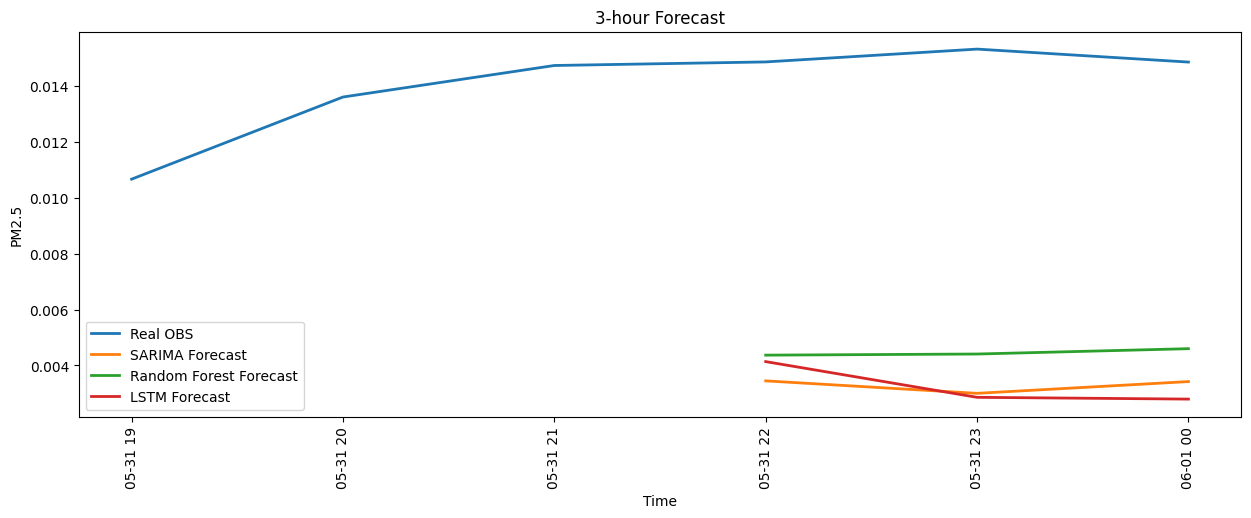

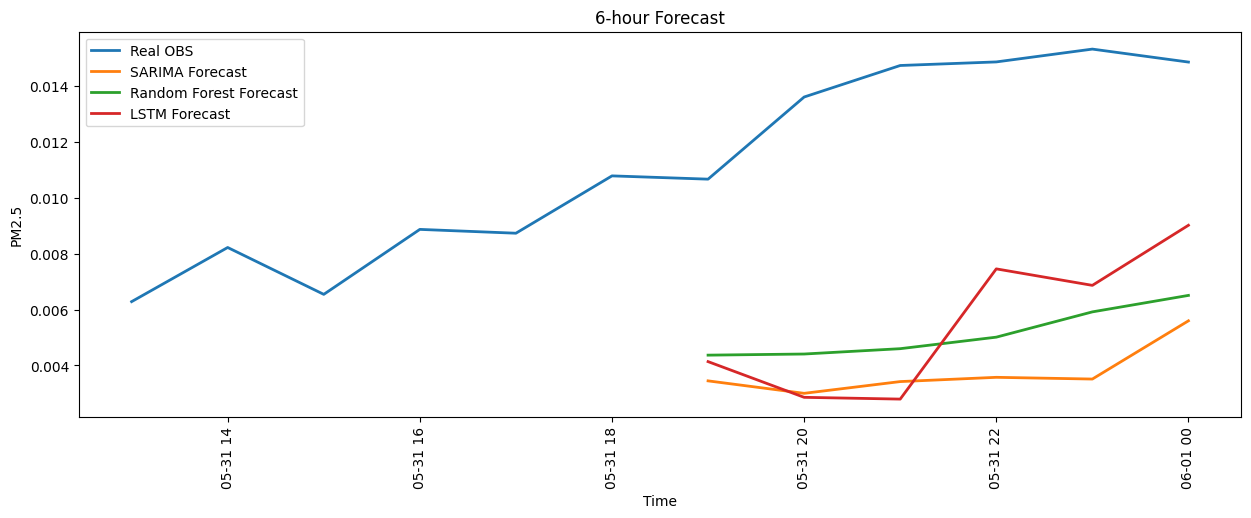

In [66]:
import matplotlib.pyplot as plt

def plot_forecasts(data, forecasts, pred_length, title):
    plt.figure(figsize=(15, 5))
    plt.plot(data.index[-(len(forecasts['SARIMA']) + pred_length):], data['PM2.5'].values[-(len(forecasts['SARIMA']) + pred_length):], label='Real OBS', linewidth=2)
    
    for name, forecast in forecasts.items():
        if isinstance(forecast, pd.Series):
            forecast = forecast.values
        plt.plot(data.index[-len(forecast):], forecast, markersize=10, label=f'{name} Forecast', linewidth=2)
    
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.show()

# Forecast dictionary for plotting
forecasts_3h = {
    'SARIMA': sarima_forecast_3h,
    'Random Forest': rf_forecast_3h,
    'LSTM': lstm_forecast_3h
}

forecasts_6h = {
    'SARIMA': sarima_forecast_6h,
    'Random Forest': rf_forecast_6h,
    'LSTM': lstm_forecast_6h
}

# Plot the forecast results
plot_forecasts(test, forecasts_3h, 3, '3-hour Forecast')
plot_forecasts(test, forecasts_6h, 6, '6-hour Forecast')


In [56]:
# # Plot Results
# plt.figure(figsize=(15, 5))
# plt.plot(test.index, test["PM2.5"], label="True")
# plt.plot(test.index, sarima_forecast_3h, label="SARIMA")
# plt.plot(test.index, rf_forecast_3h, label="Random Forest")
# plt.plot(test.index[-len(lstm_forecast_3h) :], lstm_forecast_3h, label="LSTM")
# plt.legend()
# plt.show()